#  Student Dropout Prediction — Neural Network (MLP)

**Dataset:** `student_dropout_dataset_v3.csv`  
**Task:** Binary Classification — Prediksi Dropout  
**Model:** Multi-Layer Perceptron (MLP) / Neural Network

---
###  Daftar Isi
1. Cara Melihat Tipe Data
2. Dataset Bisa Digunakan Untuk Apa
3. Model Yang Bisa Digunakan
4. Parameter Yang Bisa Diubah/Disetel
5. Evaluasi Yang Dipakai
6. Cara Mengetahui Evaluasi Bagus atau Tidak
7. Cara Mengoptimasi Model
8. Cara Menyimpan Model
9. Cara Menggunakan Model Hasil Training

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report
)

print('Libraries loaded ')

Libraries loaded 


---
## 1.  Cara Melihat Tipe Data

```python
df.info()          # Kolom, tipe data, non-null
df.dtypes          # Tipe per kolom: int64, float64, object
df.describe()      # Statistik (mean, std, min, max)
df.isnull().sum()  # Missing values
df.nunique()       # Jumlah nilai unik
```

 **Neural Network sangat sensitif terhadap skala data.** Wajib `StandardScaler` atau `MinMaxScaler`.

In [2]:
df = pd.read_csv('../student_dropout_dataset_v3.csv')
print('Shape:', df.shape)
df.info()

Shape: (10000, 19)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 19 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Student_ID             10000 non-null  int64  
 1   Age                    10000 non-null  float64
 2   Gender                 10000 non-null  object 
 3   Family_Income          9500 non-null   float64
 4   Internet_Access        10000 non-null  object 
 5   Study_Hours_per_Day    9500 non-null   float64
 6   Attendance_Rate        10000 non-null  float64
 7   Assignment_Delay_Days  10000 non-null  int64  
 8   Travel_Time_Minutes    10000 non-null  float64
 9   Part_Time_Job          10000 non-null  object 
 10  Scholarship            10000 non-null  object 
 11  Stress_Index           9500 non-null   float64
 12  GPA                    10000 non-null  float64
 13  Semester_GPA           10000 non-null  float64
 14  CGPA                   10000 non-nul

In [3]:
print('Missing Values:')
print(df.isnull().sum())
print('\nDistribusi Dropout:', dict(df['Dropout'].value_counts()))

Missing Values:
Student_ID                 0
Age                        0
Gender                     0
Family_Income            500
Internet_Access            0
Study_Hours_per_Day      500
Attendance_Rate            0
Assignment_Delay_Days      0
Travel_Time_Minutes        0
Part_Time_Job              0
Scholarship                0
Stress_Index             500
GPA                        0
Semester_GPA               0
CGPA                       0
Semester                   0
Department                 0
Parental_Education       511
Dropout                    0
dtype: int64

Distribusi Dropout: {0: np.int64(7646), 1: np.int64(2354)}


---
## 2.  Dataset Bisa Digunakan Untuk Apa

| Tujuan | Target | Jenis |
|--------|--------|-------|
| **Prediksi Dropout** ← (ini) | `Dropout` | Classification |
| Prediksi CGPA | `CGPA` | Regression |
| Deep analysis pola kompleks | - | Neural Network regression |

---
## 3.  Kenapa Neural Network (MLP)?

MLP terdiri dari lapisan-lapisan neuron yang terhubung:
```
Input Layer → Hidden Layer(s) → Output Layer
   (fitur)    (transformasi)    (prediksi)
```

**Keunggulan:**
- Bisa menangkap pola **non-linear kompleks**
- Tidak butuh feature engineering manual
- Fleksibel: bisa diatur ukuran dan kedalaman network

**Kelemahan:**
- Butuh data yang cukup banyak
- Sensitif scaling
- Lebih sulit diinterpretasi
- Risk overfitting lebih tinggi

**scikit-learn MLPClassifier vs Keras/TensorFlow:**
- `MLPClassifier` → Sederhana, cocok data lebih kecil, integrasi sklearn
- Keras/TensorFlow → Lebih fleksibel, GPU support, untuk data dan model besar

In [4]:
# Preprocessing
df_proc = df.drop(columns=['Student_ID']).copy()
le = LabelEncoder()
for col in df_proc.select_dtypes(include='object').columns:
    df_proc[col] = le.fit_transform(df_proc[col].astype(str))

X = df_proc.drop(columns=['Dropout'])
y = df_proc['Dropout']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Imputasi nilai null dengan median
imputer = SimpleImputer(strategy='median')
X_train_imp = imputer.fit_transform(X_train)
X_test_imp  = imputer.transform(X_test)

# WAJIB scaling
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train_imp)
X_test_s  = scaler.transform(X_test_imp)

print(f'Train: {X_train_s.shape}, Test: {X_test_s.shape}')

Train: (8000, 17), Test: (2000, 17)


---
## 4.  Parameter Yang Bisa Diubah / Disetel

| Parameter | Default | Penjelasan |
|-----------|---------|------------|
| `hidden_layer_sizes` | `(100,)` | Arsitektur jaringan. `(100, 50)` = 2 hidden layers, 100 dan 50 neuron |
| `activation` | `'relu'` | Fungsi aktivasi: `'relu'`, `'tanh'`, `'logistic'` |
| `solver` | `'adam'` | Optimizer: `'adam'` (adaptif, default), `'sgd'` (stochastic), `'lbfgs'` |
| `alpha` | 0.0001 | L2 regularization. Naikkan untuk atasi overfitting |
| `learning_rate` | `'constant'` | `'constant'`, `'invscaling'`, `'adaptive'` |
| `learning_rate_init` | 0.001 | Learning rate awal (untuk adam dan sgd) |
| `max_iter` | 200 | Maksimum iterasi epoch |
| `early_stopping` | False | Set `True` untuk stop jika validation tidak membaik |
| `validation_fraction` | 0.1 | Proporsi validation set saat early stopping |
| `n_iter_no_change` | 10 | Berapa epoch tidak ada improvement sebelum stop |
| `batch_size` | `'auto'` | Ukuran batch gradient descent |
| `random_state` | None | Seed |

In [5]:
# Build MLP Neural Network
model = MLPClassifier(
    hidden_layer_sizes=(128, 64, 32),  # Arsitektur: 3 hidden layers
    activation='relu',                  # 'relu', 'tanh', 'logistic'
    solver='adam',                      # Optimizer
    alpha=0.001,                        # L2 regularization (coba: 0.0001, 0.001, 0.01)
    learning_rate='adaptive',           # Adaptif jika training tidak converge
    learning_rate_init=0.001,           # Initial learning rate
    max_iter=300,                       # Maksimum epoch
    early_stopping=True,                # Stop jika tidak ada perbaikan
    validation_fraction=0.1,            # 10% untuk validasi saat early stopping
    n_iter_no_change=20,                # Tunggu 20 epoch tanpa improve
    batch_size='auto',
    random_state=42,
    verbose=False
)

model.fit(X_train_s, y_train)
print(f'Model Neural Network berhasil ditraining ')
print(f'Jumlah iterasi aktual: {model.n_iter_}')
print(f'Loss akhir: {model.loss_:.4f}')

Model Neural Network berhasil ditraining 
Jumlah iterasi aktual: 24
Loss akhir: 0.3172


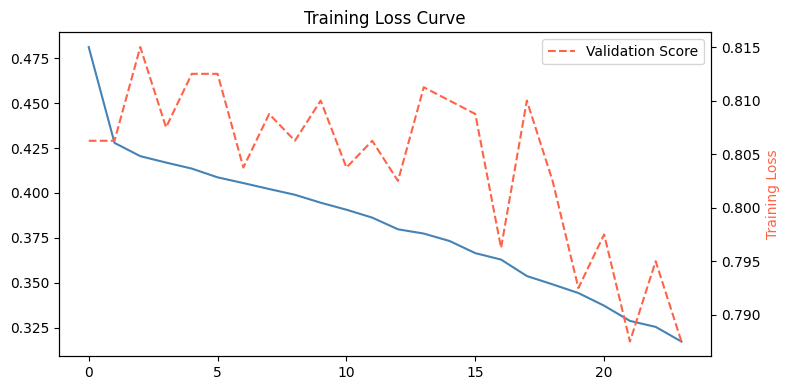

In [6]:
# Plot learning curve
plt.figure(figsize=(8, 4))
plt.plot(model.loss_curve_, label='Training Loss', color='steelblue')
if hasattr(model, 'validation_scores_') and model.validation_scores_ is not None:
    plt.twinx()
    plt.plot(model.validation_scores_, label='Validation Score', color='tomato', linestyle='--')
    plt.ylabel('Validation Score', color='tomato')
plt.xlabel('Epoch')
plt.ylabel('Training Loss')
plt.title('Training Loss Curve')
plt.legend()
plt.tight_layout()
plt.show()

In [7]:
y_pred = model.predict(X_test_s)
y_pred_proba = model.predict_proba(X_test_s)[:, 1]

---
## 5.  Evaluasi Yang Dipakai

In [8]:
print('=' * 55)
print(' EVALUASI MODEL NEURAL NETWORK')
print('=' * 55)
print(f'Accuracy  : {accuracy_score(y_test, y_pred):.4f}')
print(f'Precision : {precision_score(y_test, y_pred):.4f}')
print(f'Recall    : {recall_score(y_test, y_pred):.4f}')
print(f'F1-Score  : {f1_score(y_test, y_pred):.4f}')
print(f'ROC-AUC   : {roc_auc_score(y_test, y_pred_proba):.4f}')
print()
print(classification_report(y_test, y_pred, target_names=['Tidak Dropout', 'Dropout']))

 EVALUASI MODEL NEURAL NETWORK
Accuracy  : 0.8120
Precision : 0.6766
Recall    : 0.3864
F1-Score  : 0.4919
ROC-AUC   : 0.8183

               precision    recall  f1-score   support

Tidak Dropout       0.83      0.94      0.88      1529
      Dropout       0.68      0.39      0.49       471

     accuracy                           0.81      2000
    macro avg       0.75      0.66      0.69      2000
 weighted avg       0.80      0.81      0.79      2000



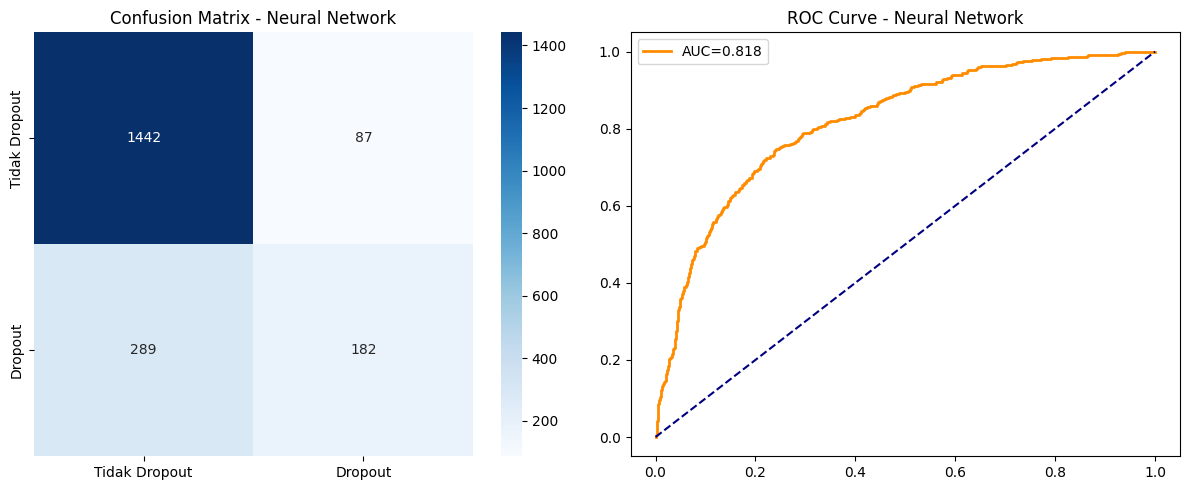

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Tidak Dropout', 'Dropout'],
            yticklabels=['Tidak Dropout', 'Dropout'], ax=axes[0])
axes[0].set_title('Confusion Matrix - Neural Network')

from sklearn.metrics import roc_curve
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
axes[1].plot(fpr, tpr, 'darkorange', lw=2, label=f'AUC={roc_auc_score(y_test,y_pred_proba):.3f}')
axes[1].plot([0,1],[0,1],'navy',linestyle='--')
axes[1].set_title('ROC Curve - Neural Network')
axes[1].legend()
plt.tight_layout()
plt.show()

---
## 6.  Cara Mengetahui Evaluasi Bagus atau Tidak

### Metrik Classification:
| Metrik | Buruk | Cukup | Baik | Sangat Baik |
|--------|-------|-------|------|-------------|
| Accuracy | < 65% | 65-75% | 75-85% | > 85% |
| F1-Score | < 0.6 | 0.6-0.7 | 0.7-0.8 | > 0.8 |
| ROC-AUC | < 0.65 | 0.65-0.75 | 0.75-0.85 | > 0.85 |

### Deteksi Overfitting untuk NN:
- Loss training turun, validation loss naik setelah titik tertentu → **Overfitting**
- Solusi: Naikkan `alpha`, aktifkan `early_stopping`, kurangi ukuran jaringan

### Underfitting:
- Loss tinggi dan tidak turun signifikan
- Solusi: Tambah neuron, tambah layer, tambah epoch

In [10]:
train_acc = accuracy_score(y_train, model.predict(X_train_s))
test_acc = accuracy_score(y_test, y_pred)
print(f'Train Accuracy : {train_acc:.4f}')
print(f'Test Accuracy  : {test_acc:.4f}')
if train_acc - test_acc > 0.05:
    print('  OVERFITTING — Naikkan alpha, kurangi hidden layers, atau kurangi neuron')
elif test_acc < 0.7:
    print('  UNDERFITTING — Tambah neuron, layer, atau epoch')
else:
    print('  Model terlihat sehat!')

Train Accuracy : 0.8131
Test Accuracy  : 0.8120
  Model terlihat sehat!


---
## 7.  Cara Mengoptimasi Model

### Teknik Regularisasi Neural Network:

| Teknik | Cara | Parameter |
|--------|------|----------|
| **L2 Regularization** | Penalti pada bobot besar | `alpha` (naikkan) |
| **Early Stopping** | Hentikan sebelum overfit | `early_stopping=True` |
| **Arsitektur lebih kecil** | Kurangi kapasitas | `hidden_layer_sizes` lebih kecil |
| **Dropout** | MLPClassifier tidak support dropout langsung (gunakan Keras) | - |

### Arsitektur yang umum dicoba:
```python
# Kecil
hidden_layer_sizes=(64,)

# Medium (default area)
hidden_layer_sizes=(128, 64)

# Lebih dalam
hidden_layer_sizes=(256, 128, 64, 32)
```

### Tips Learning Rate:
- `learning_rate_init=0.001` biasanya baik
- Jika loss tidak turun: coba lebih kecil `0.0001`
- Jika training sangat lambat: coba lebih besar `0.01`

In [11]:
# Eksperimen dengan berbagai arsitektur
architectures = [
    (64,),
    (128, 64),
    (256, 128, 64),
    (128, 64, 32)
]

results = []
for arch in architectures:
    m = MLPClassifier(
        hidden_layer_sizes=arch,
        activation='relu',
        solver='adam',
        alpha=0.001,
        max_iter=200,
        early_stopping=True,
        random_state=42,
        verbose=False
    )
    m.fit(X_train_s, y_train)
    yp = m.predict(X_test_s)
    results.append({
        'Architecture': str(arch),
        'Accuracy': accuracy_score(y_test, yp),
        'F1': f1_score(y_test, yp),
        'AUC': roc_auc_score(y_test, m.predict_proba(X_test_s)[:, 1]),
        'Epochs': m.n_iter_
    })

pd.DataFrame(results).sort_values('AUC', ascending=False)

,Architecture,Accuracy,F1,AUC,Epochs
3,"(128, 64, 32)",0.8120,0.491892,0.818261,14
2,"(256, 128, 64)",0.8115,0.509753,0.814040,13
0,"(64,)",0.8065,0.494118,0.811875,23
1,"(128, 64)",0.8015,0.397572,0.801504,12


---
## 8.  Cara Menyimpan Model

In [12]:
os.makedirs('saved_models', exist_ok=True)

# Simpan model terbaik
best_arch = (128, 64, 32)  # Ganti dengan arsitektur terbaik dari eksperimen
best_nn = MLPClassifier(
    hidden_layer_sizes=best_arch,
    activation='relu', solver='adam', alpha=0.001,
    max_iter=300, early_stopping=True, random_state=42
)
best_nn.fit(X_train_s, y_train)

joblib.dump(best_nn, 'saved_models/neural_network_dropout.pkl')
joblib.dump(scaler, 'saved_models/scaler_nn.pkl')
joblib.dump(list(X.columns), 'saved_models/feature_columns_nn.pkl')

print(' Neural Network model tersimpan!')
print(f'File size: {os.path.getsize("saved_models/neural_network_dropout.pkl") / 1024:.1f} KB')

 Neural Network model tersimpan!
File size: 305.4 KB


---
## 9.  Cara Menggunakan Model Hasil Training

In [13]:
loaded_model = joblib.load('saved_models/neural_network_dropout.pkl')
loaded_scaler = joblib.load('saved_models/scaler_nn.pkl')
loaded_cols = joblib.load('saved_models/feature_columns_nn.pkl')

print('Model Neural Network dimuat ')

# Data baru
new_data = pd.DataFrame([{
    'Age': 20, 'Gender': 0, 'Family_Income': 20000,
    'Internet_Access': 1, 'Study_Hours_per_Day': 3.0,
    'Attendance_Rate': 78, 'Assignment_Delay_Days': 2,
    'Travel_Time_Minutes': 25, 'Part_Time_Job': 0,
    'Scholarship': 1, 'Stress_Index': 5,
    'GPA': 2.8, 'Semester_GPA': 2.7, 'CGPA': 2.75,
    'Semester': 3, 'Department': 1, 'Parental_Education': 2
}])[loaded_cols]

# WAJIB scale
new_data_scaled = loaded_scaler.transform(new_data)

pred = loaded_model.predict(new_data_scaled)[0]
prob = loaded_model.predict_proba(new_data_scaled)[0]

print(f'\nPrediksi: {" DROPOUT" if pred == 1 else " TIDAK DROPOUT"}')
print(f'Probabilitas Dropout       : {prob[1]:.2%}')
print(f'Probabilitas Tidak Dropout : {prob[0]:.2%}')

# Tingkat risiko
risk = ' TINGGI' if prob[1] > 0.7 else (' SEDANG' if prob[1] > 0.4 else ' RENDAH')
print(f'Tingkat Risiko: {risk}')

Model Neural Network dimuat 

Prediksi:  TIDAK DROPOUT
Probabilitas Dropout       : 10.15%
Probabilitas Tidak Dropout : 89.85%
Tingkat Risiko:  RENDAH
